## Extracting features from data traces retrieved using WebPlotDigitizer

#### Ilaria Carannante
mailto: ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

### Code source

This notebook uses code originally developed and published in:

Guarino, D.*, Carannante, I.*, and Destexhe, A. (2025).  
*A unified model library maps how neuromodulation reshapes the excitability landscape of neurons across the brain.*  
PLOS Computational Biology, 21(12): e1013765.  
https://doi.org/10.1371/journal.pcbi.1013765

The code is reproduced here for demonstration and analysis purposes.

This notebook is meant to be an example showing how to extract selected features from a trace which was retrieved from the figure of a paper using WebPlotDigitizer.

In [1]:
# importing libraries

import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import ast
import os
import json

from scipy.interpolate import interp1d
from Features_extraction_helper import *

In [2]:
# Selecting the brain region, species and condition to analyze
# Metadata

brain_region = 'cortex'
species = 'human'
condition = 'control'

#brain_region = 'hippocampus'
#species = 'mouse'
#condition = 'control'

data_folder = os.path.join('data', 'data_traces', brain_region, species, condition )

In [3]:
# Listing the available data traces
os.listdir(data_folder)

['.ipynb_checkpoints', 'McCormickWilliamson1989_fig1B.csv']

In [4]:
# The user can select the data trace depending on the available file (list printed out in previous cell)
file_name = 'McCormickWilliamson1989_fig1B.csv'
#file_name = 'CarverShapiro2019_fig5A_100pA.csv'

In [5]:
# Reading the file
data_file_1 = os.path.join(data_folder, file_name)
trace_1 = np.loadtxt(data_file_1, delimiter = ',')

In [6]:
# Saving time a voltage. They represent the first and second column of the file, respectively.
time_ms = trace_1[:, 0] - trace_1[0,0] # subtracting trace_1[0,0] to make sure that the time starts from zero
voltage_mV = trace_1[:, 1]

Text(0.5, 1.0, 'Trace from: McCormickWilliamson1989_fig1B \n brain region: cortex -- species: human -- condition: control')

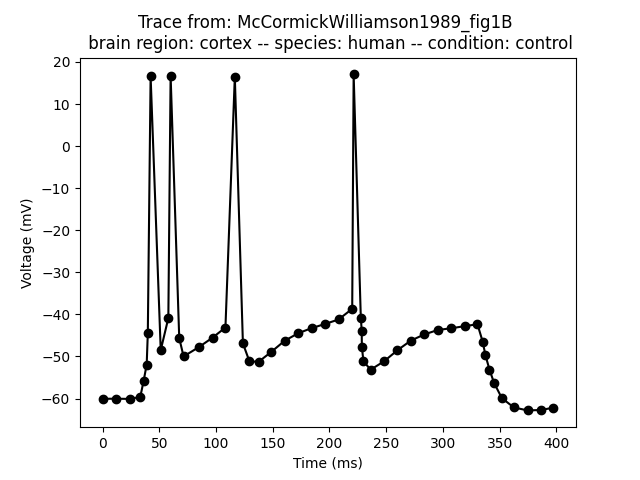

In [7]:
# Plotting the data to show the "low discretization"
plt.figure()
plt.plot(time_ms, voltage_mV, 'o-', color = 'black')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title(f'Trace from: {file_name[:-4]} \n brain region: {brain_region} -- species: {species} -- condition: {condition}')

In [8]:
# Retriveing information from the data_collectin_curation file
df = pd.read_csv(os.path.join('data','data_traces','data_collection_curation.csv'),sep=',')

In [9]:
# Showing the metadata of the collecting traces
df

,input_region,species,condition,publication,file_name,Temperature (Celsius),holding_voltage (mV),voltage_peak (mV),voltage_threshold (mV),reset_voltage (mV),holding_current (pA),"current_injection_protocol ([ms],[pA])",comments
0,cortex,human,control,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1A.csv,35±1,-60,17.0,~ -44,~ -51,0,"[0, 33, 333, 400], [0, 800, 0]",NaN
1,cortex,human,control,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1B.csv,35±1,-60,17.0,~ -44,~ -51,0,"[0, 33, 333, 400], [0, 800, 0]",NaN
2,cortex,human,control,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1D.csv,35±1,-60,17.0,~ -44,~ -51,0,"[0, 33, 333, 400], [0, 800, 0]",NaN
3,cortex,human,histamine,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1_HT.csv,35±1,-60,11.0,~ -44,~ -49.5,0,"[0, 37, 330, 400], [0, 800, 0]",NaN
4,cortex,human,methacoline,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1_MCh.csv,35±1,-60,15.5,~ -44,~ -52,0,"[0, 37, 335, 400], [0, 800, 0]",NaN
5,cortex,human,norepinephrine,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1_NA.csv,35±1,-60,11.0,~ -45,~ -57,0,"[0, 33, 345, 400], [0, 800, 0]",NaN
6,cortex,human,serotonin,"McCormick and Williamson., 1989",McCormickWilliamson1989_fig1_5HT.csv,35±1,-60,11.0,~ -44,~ -52,0,"[0, 33, 330, 400], [0, 800, 0]",NaN
7,cortex,rat,control,"Onn et al., 2006",Onn2006_fig3a1.csv,31-32,-66,-7.5,~ -50,~ -51.5,0,"[0, 25, 80, 100], [0, 1400, 0]",NaN
8,cortex,rat,dopamine,"Onn et al., 2006",Onn2006_fig3a2_DA.csv,31-32,-67,-7.5,~ -46.5,~ -49.5,0,"[0, 25, 80, 100], [0, 1400, 0]",NaN


In [10]:
file_name

'McCormickWilliamson1989_fig1B.csv'

In [11]:
# Finding the row corresponding to the selected file
row_index = df.index[df["file_name"] == file_name][0]

In [12]:
# Retrieving the current injection protocol 
curr_inj_prot = df['current_injection_protocol ([ms],[pA])'][row_index]

times_curr_inj_prot, amplitudes_curr_inj_prot = ast.literal_eval(f"[{curr_inj_prot}]")

print("Times (ms):", times_curr_inj_prot)
print("Amplitudes (pA):", amplitudes_curr_inj_prot)

Times (ms): [0, 33, 333, 400]
Amplitudes (pA): [0, 800, 0]


In [13]:
# Saving the information on the stimulus in the needed format
stim_delay = times_curr_inj_prot[1]
stim_end = times_curr_inj_prot[2]
stim_duration = stim_end - stim_delay
duration = times_curr_inj_prot[3]

curr = amplitudes_curr_inj_prot[1]

In [14]:
# stimulation protocol to save in the json file
stimulation_protocol = [times_curr_inj_prot, amplitudes_curr_inj_prot]

In [15]:
# Because of the very low discretization of the trace we need to improve the resolution. We do that by interpolating the data.
dt = 0.01
fine_time_ms = np.arange(time_ms[0], time_ms[-1], dt)  # 0.01 ms resolution

interpolator = interp1d(time_ms, voltage_mV, kind='linear')
fine_voltage_mV = interpolator(fine_time_ms)


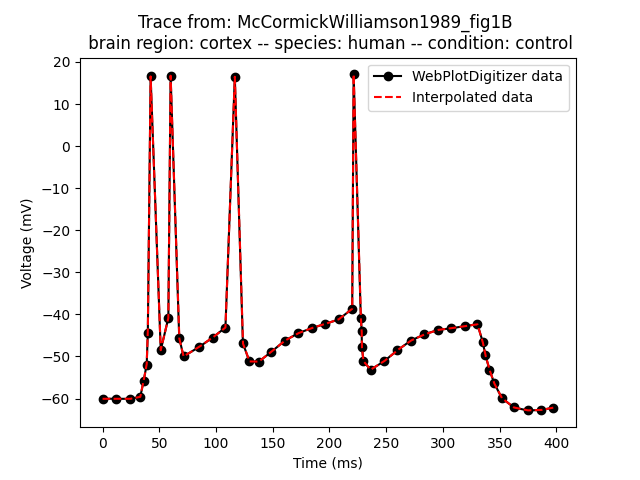

In [16]:
plt.figure()
plt.plot(trace_1[:,0]- trace_1[0,0], trace_1[:,1],'o-' ,color = 'black', label = 'WebPlotDigitizer data')
plt.plot(fine_time_ms, fine_voltage_mV, '--', color = 'red', label = 'Interpolated data')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title(f'Trace from: {file_name[:-4]} \n brain region: {brain_region} -- species: {species} -- condition: {condition}')
plt.legend()

In [17]:
# Extracting the key features. Calling function in Features_extraction_helper.py file
features = data_extract_features(fine_time_ms, fine_voltage_mV, stim_delay, stim_duration, curr, dt)

# Extract values
freq = round(features[0][1], 2)
inv_first_ISI = round(features[0][2], 2)
inv_last_ISI = round(features[0][3], 2)
time_to_first_spike = round(features[0][4], 2)
time_to_second_spike = round(features[0][5], 2)
time_to_third_spike = round(features[0][6], 2)
time_to_last_spike = round(features[0][7], 2)
volt_stimend = round(features[0][8], 2) if features[0][8] is not None else None

In [18]:
print(f"""
Feature summary for {file_name}
-------------------------------
Species: {species}
Brain region: {brain_region}
Condition: {condition}

Frequency: {freq} Hz
Inverse first ISI: {inv_first_ISI} Hz
Inverse last ISI: {inv_last_ISI} Hz
Time to first spike: {time_to_first_spike} ms
Time to second spike: {time_to_second_spike} ms
Time to third spike: {time_to_third_spike} ms
Time to last spike: {time_to_last_spike} ms
Steady state voltage stim end: {f"{round(volt_stimend, 2)}" if volt_stimend is not None else "N/A"} mV
""")


Feature summary for McCormickWilliamson1989_fig1B.csv
-------------------------------
Species: human
Brain region: cortex
Condition: control

Frequency: 13.33 Hz
Inverse first ISI: 56.63 Hz
Inverse last ISI: 9.48 Hz
Time to first spike: 9.11 ms
Time to second spike: 26.77 ms
Time to third spike: 82.71 ms
Time to last spike: 188.19 ms
Steady state voltage stim end: N/A mV



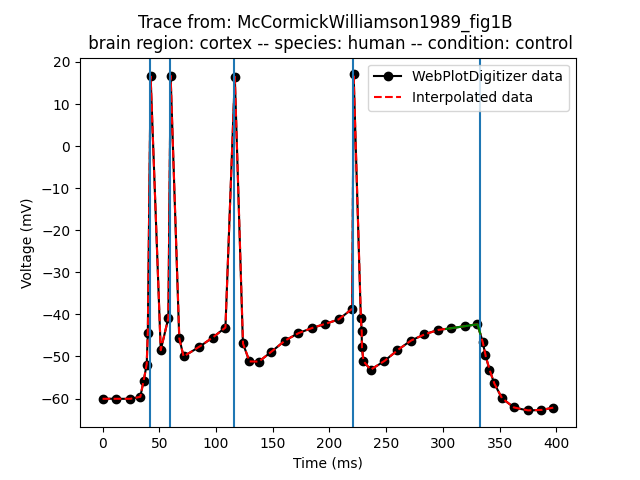

In [19]:
# Plotting the trace and the extracted features

plt.figure()
plt.plot(trace_1[:,0]- trace_1[0,0], trace_1[:,1],'o-' ,color = 'black', label = 'WebPlotDigitizer data')
plt.plot(fine_time_ms, fine_voltage_mV, '--', color = 'red', label = 'Interpolated data')
plt.axvline(x = time_to_first_spike + stim_delay)
plt.axvline(x = time_to_second_spike + stim_delay)
plt.axvline(x = time_to_third_spike + stim_delay)
plt.axvline(x = time_to_last_spike + stim_delay)

index_end_stim = int((stim_delay+stim_duration)/dt)
plt.axvline(x = fine_time_ms[index_end_stim])

if volt_stimend is not None:
    plt.axhline(y = volt_stimend)
plt.plot(fine_time_ms[index_end_stim - int(30/dt): index_end_stim], fine_voltage_mV[index_end_stim - int(30/dt): index_end_stim], color='green')

plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title(f'Trace from: {file_name[:-4]} \n brain region: {brain_region} -- species: {species} -- condition: {condition}')
plt.legend()

In [20]:
# Features to append to json 
features_to_append = {'file_name': file_name,
                      'stimulation_protocol': stimulation_protocol,
                      'current': [features[0][0]],
                      'mean_frequency': [freq],
                      'inv_first_ISI': [inv_first_ISI],
                      'inv_last_ISI': [inv_last_ISI],
                      'time_to_first_spike': [time_to_first_spike],
                      'time_to_second_spike': [time_to_second_spike],
                      'time_to_third_spike': [time_to_third_spike],
                      'time_to_last_spike': [time_to_last_spike],
                      'volt_stimend' : [volt_stimend]}

In [21]:
# Appenging the features to a json file called extracting_features_test.json
append_to_json_file('extracting_features_test.json', features_to_append)